In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gc
from sklearn.metrics import roc_auc_score

PROCESSED = Path("../data/processed")
REPORTS = Path("reports")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
bureau = pd.read_parquet(PROCESSED / "bureau.parquet")
train_target = pd.read_parquet(
    PROCESSED / "application_train_reduced.parquet",
    columns=["SK_ID_CURR", "TARGET"]
)
print(f"Bureau: {bureau.shape}")
print(f"Train target: {train_target.shape}")
print(f"Memoria bureau: {bureau.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nDtypes:")
print(bureau.dtypes.value_counts())
print(f"\nHead:")
print(bureau.head(3))

Bureau: (1716428, 17)
Train target: (307511, 2)
Memoria bureau: 409.0 MB

Dtypes:
float64    6
int32      3
object     3
int16      2
float32    2
int8       1
Name: count, dtype: int64

Head:
   SK_ID_CURR  SK_ID_BUREAU CREDIT_ACTIVE CREDIT_CURRENCY  DAYS_CREDIT  \
0      215354       5714462        Closed      currency 1         -497   
1      215354       5714463        Active      currency 1         -208   
2      215354       5714464        Active      currency 1         -203   

   CREDIT_DAY_OVERDUE  DAYS_CREDIT_ENDDATE  DAYS_ENDDATE_FACT  \
0                   0               -153.0             -153.0   
1                   0               1075.0                NaN   
2                   0                528.0                NaN   

   AMT_CREDIT_MAX_OVERDUE  CNT_CREDIT_PROLONG  AMT_CREDIT_SUM  \
0                     NaN                   0         91323.0   
1                     NaN                   0        225000.0   
2                     NaN                   0        4

Clientes únicos en bureau:        305,811
Clientes en application_train:    307,511
Clientes train con historial:     263,491 (85.69%)
Clientes train SIN historial:     44,020

=== Créditos previos por cliente ===
count    305811.0
mean          5.6
std           4.4
min           1.0
25%           2.0
50%           4.0
75%           8.0
max         116.0
dtype: float64

Distribución (top 15):
1     41520
2     41004
3     37828
4     33467
5     28913
6     24329
7     20095
8     16736
9     13073
10    10518
11     8456
12     6564
13     5144
14     4129
15     3061
Name: count, dtype: int64


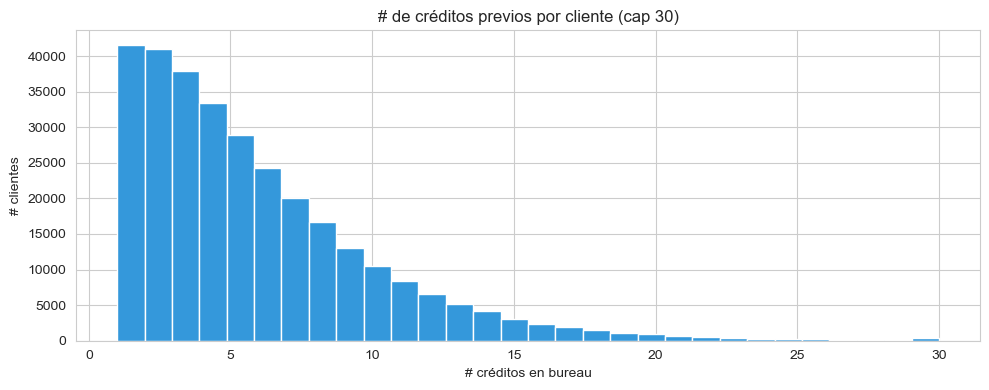

In [3]:
n_clients_bureau = bureau["SK_ID_CURR"].nunique()
n_clients_train = train_target["SK_ID_CURR"].nunique()
train_with_bureau = train_target["SK_ID_CURR"].isin(bureau["SK_ID_CURR"]).sum()

print(f"Clientes únicos en bureau:        {n_clients_bureau:,}")
print(f"Clientes en application_train:    {n_clients_train:,}")
print(f"Clientes train con historial:     {train_with_bureau:,} "
      f"({100*train_with_bureau/n_clients_train:.2f}%)")
print(f"Clientes train SIN historial:     {n_clients_train - train_with_bureau:,}")

counts_per_client = bureau.groupby("SK_ID_CURR").size()
print(f"\n=== Créditos previos por cliente ===")
print(counts_per_client.describe().round(1))
print(f"\nDistribución (top 15):")
print(counts_per_client.value_counts().sort_index().head(15))

# Histograma
fig, ax = plt.subplots(figsize=(10, 4))
counts_per_client.clip(upper=30).hist(bins=30, ax=ax, color="#3498db")
ax.set_title("# de créditos previos por cliente (cap 30)")
ax.set_xlabel("# créditos en bureau")
ax.set_ylabel("# clientes")
plt.tight_layout()
plt.savefig(REPORTS / "bureau_credits_per_client.png", dpi=80, bbox_inches="tight")
plt.show()

In [4]:
for col in ["CREDIT_ACTIVE", "CREDIT_CURRENCY", "CREDIT_TYPE"]:
    print(f"\n=== {col} ===")
    vc = bureau[col].value_counts(dropna=False)
    pct = (vc / len(bureau) * 100).round(2)
    print(pd.DataFrame({"count": vc, "pct": pct}))


=== CREDIT_ACTIVE ===
                 count    pct
CREDIT_ACTIVE                
Closed         1079273  62.88
Active          630607  36.74
Sold              6527   0.38
Bad debt            21   0.00

=== CREDIT_CURRENCY ===
                   count    pct
CREDIT_CURRENCY                
currency 1       1715020  99.92
currency 2          1224   0.07
currency 3           174   0.01
currency 4            10   0.00

=== CREDIT_TYPE ===
                                                count    pct
CREDIT_TYPE                                                 
Consumer credit                               1251615  72.92
Credit card                                    402195  23.43
Car loan                                        27690   1.61
Mortgage                                        18391   1.07
Microloan                                       12413   0.72
Loan for business development                    1975   0.12
Another type of loan                             1017   0.06
Unknown ty

In [5]:
num_cols = bureau.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ("SK_ID_CURR", "SK_ID_BUREAU")]

print(f"=== Numéricas ({len(num_cols)}) ===")
print(bureau[num_cols].describe().round(1))

print("\n=== % nulos ordenado ===")
nulls_b = (bureau[num_cols].isna().mean() * 100).round(2).sort_values(ascending=False)
print(nulls_b)

=== Numéricas (12) ===
       DAYS_CREDIT  CREDIT_DAY_OVERDUE  DAYS_CREDIT_ENDDATE  \
count    1716428.0           1716428.0            1610875.0   
mean       -1142.1                 0.8                510.5   
std          795.2                36.5               4985.5   
min        -2922.0                 0.0             -42060.0   
25%        -1666.0                 0.0              -1138.0   
50%         -987.0                 0.0               -330.0   
75%         -474.0                 0.0                474.0   
max            0.0              2792.0              31199.0   

       DAYS_ENDDATE_FACT  AMT_CREDIT_MAX_OVERDUE  CNT_CREDIT_PROLONG  \
count          1082775.0                591940.0           1716428.0   
mean             -1017.4                  3825.4                 0.0   
std                713.8                206031.6                 0.1   
min             -42023.0                     0.0                 0.0   
25%              -1489.0                     0.0 

In [6]:
days_cols_b = [c for c in bureau.columns if c.startswith("DAYS_")]
print(f"Columnas DAYS_* en bureau: {days_cols_b}\n")

for col in days_cols_b:
    s = bureau[col].dropna()
    print(f"{col}:")
    print(f"  min={s.min():>10.0f} | max={s.max():>10.0f} | mean={s.mean():>10.0f}")
    n_pos = (s > 0).sum()
    n_extreme = (s.abs() > 100000).sum()
    print(f"  valores positivos: {n_pos:,} | |valor|>100k: {n_extreme:,}")

Columnas DAYS_* en bureau: ['DAYS_CREDIT', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'DAYS_CREDIT_UPDATE']

DAYS_CREDIT:
  min=     -2922 | max=         0 | mean=     -1142
  valores positivos: 0 | |valor|>100k: 0
DAYS_CREDIT_ENDDATE:
  min=    -42060 | max=     31199 | mean=       511
  valores positivos: 602,603 | |valor|>100k: 0
DAYS_ENDDATE_FACT:
  min=    -42023 | max=         0 | mean=     -1017
  valores positivos: 0 | |valor|>100k: 0
DAYS_CREDIT_UPDATE:
  min=    -41947 | max=       372 | mean=      -594
  valores positivos: 17 | |valor|>100k: 0


In [7]:
# Agregaciones generales
agg_dict = {
    "SK_ID_BUREAU": "count",
    "DAYS_CREDIT": ["min", "max", "mean"],
    "DAYS_CREDIT_ENDDATE": ["min", "max", "mean"],
    "CREDIT_DAY_OVERDUE": ["max", "mean"],
    "AMT_CREDIT_SUM": ["sum", "mean", "max"],
    "AMT_CREDIT_SUM_DEBT": ["sum", "mean"],
    "AMT_CREDIT_SUM_OVERDUE": ["sum", "max"],
    "AMT_CREDIT_MAX_OVERDUE": "max",
    "CNT_CREDIT_PROLONG": "sum",
    "DAYS_CREDIT_UPDATE": "mean",
}

bureau_agg = bureau.groupby("SK_ID_CURR").agg(agg_dict)
bureau_agg.columns = ["BUR_" + "_".join(c).upper() for c in bureau_agg.columns]
bureau_agg = bureau_agg.rename(columns={"BUR_SK_ID_BUREAU_COUNT": "BUR_N_CREDITS"})
bureau_agg = bureau_agg.reset_index()

print(f"bureau_agg shape: {bureau_agg.shape}")
print(f"Columnas generadas: {len(bureau_agg.columns) - 1}")
bureau_agg.head(3)

bureau_agg shape: (305811, 20)
Columnas generadas: 19


,SK_ID_CURR,BUR_N_CREDITS,BUR_DAYS_CREDIT_MIN,BUR_DAYS_CREDIT_MAX,BUR_DAYS_CREDIT_MEAN,BUR_DAYS_CREDIT_ENDDATE_MIN,BUR_DAYS_CREDIT_ENDDATE_MAX,BUR_DAYS_CREDIT_ENDDATE_MEAN,BUR_CREDIT_DAY_OVERDUE_MAX,BUR_CREDIT_DAY_OVERDUE_MEAN,BUR_AMT_CREDIT_SUM_SUM,BUR_AMT_CREDIT_SUM_MEAN,BUR_AMT_CREDIT_SUM_MAX,BUR_AMT_CREDIT_SUM_DEBT_SUM,BUR_AMT_CREDIT_SUM_DEBT_MEAN,BUR_AMT_CREDIT_SUM_OVERDUE_SUM,BUR_AMT_CREDIT_SUM_OVERDUE_MAX,BUR_AMT_CREDIT_MAX_OVERDUE_MAX,BUR_CNT_CREDIT_PROLONG_SUM,BUR_DAYS_CREDIT_UPDATE_MEAN
0,100001,7,-1572,-49,-735.00,-1329.0,1778.0,82.428574,0,0.0,1453365.000,207623.571429,378000.0,596686.5,85240.928571,0.0,0.0,NaN,0,-93.142857
1,100002,8,-1437,-103,-874.00,-1072.0,780.0,-349.000000,0,0.0,865055.565,108131.945625,450000.0,245781.0,49156.200000,0.0,0.0,5043.645,0,-499.875000
2,100003,4,-2586,-606,-1400.75,-2434.0,1216.0,-544.500000,0,0.0,1017400.500,254350.125000,810000.0,0.0,0.000000,0.0,0.0,0.000,0,-816.000000


In [8]:
# Créditos activos
active = bureau[bureau["CREDIT_ACTIVE"] == "Active"].groupby("SK_ID_CURR").agg(
    BUR_ACTIVE_COUNT=("SK_ID_BUREAU", "count"),
    BUR_ACTIVE_DEBT_SUM=("AMT_CREDIT_SUM_DEBT", "sum"),
    BUR_ACTIVE_OVERDUE_MAX=("AMT_CREDIT_SUM_OVERDUE", "max"),
)

# Créditos cerrados
closed = bureau[bureau["CREDIT_ACTIVE"] == "Closed"].groupby("SK_ID_CURR").agg(
    BUR_CLOSED_COUNT=("SK_ID_BUREAU", "count"),
)

bureau_agg = bureau_agg.merge(active, on="SK_ID_CURR", how="left")
bureau_agg = bureau_agg.merge(closed, on="SK_ID_CURR", how="left")

# Conteos faltantes = 0 (no tenía créditos de esa categoría)
for col in ["BUR_ACTIVE_COUNT", "BUR_ACTIVE_DEBT_SUM", "BUR_ACTIVE_OVERDUE_MAX", "BUR_CLOSED_COUNT"]:
    bureau_agg[col] = bureau_agg[col].fillna(0)

# Ratio activos/totales (info adicional)
bureau_agg["BUR_ACTIVE_RATIO"] = (
    bureau_agg["BUR_ACTIVE_COUNT"] / bureau_agg["BUR_N_CREDITS"]
).clip(0, 1).astype("float32")

print(f"Shape final: {bureau_agg.shape}")
print(f"\nMuestra:")
print(bureau_agg.head(3))

Shape final: (305811, 25)

Muestra:
   SK_ID_CURR  BUR_N_CREDITS  BUR_DAYS_CREDIT_MIN  BUR_DAYS_CREDIT_MAX  \
0      100001              7                -1572                  -49   
1      100002              8                -1437                 -103   
2      100003              4                -2586                 -606   

   BUR_DAYS_CREDIT_MEAN  BUR_DAYS_CREDIT_ENDDATE_MIN  \
0               -735.00                      -1329.0   
1               -874.00                      -1072.0   
2              -1400.75                      -2434.0   

   BUR_DAYS_CREDIT_ENDDATE_MAX  BUR_DAYS_CREDIT_ENDDATE_MEAN  \
0                       1778.0                     82.428574   
1                        780.0                   -349.000000   
2                       1216.0                   -544.500000   

   BUR_CREDIT_DAY_OVERDUE_MAX  BUR_CREDIT_DAY_OVERDUE_MEAN  \
0                           0                          0.0   
1                           0                          0.0   

In [9]:
bureau_target = bureau_agg.merge(train_target, on="SK_ID_CURR", how="inner")
print(f"Clientes con bureau + target: {bureau_target.shape}")

agg_features = [c for c in bureau_target.columns if c.startswith("BUR_")]
auc_list = []
for col in agg_features:
    x = bureau_target[col].fillna(bureau_target[col].median())
    if x.nunique() < 2:
        continue
    auc_raw = roc_auc_score(bureau_target["TARGET"], x)
    auc_list.append({
        "feature": col,
        "auc": round(max(auc_raw, 1 - auc_raw), 4),
        "direction": "↓ menos default" if auc_raw < 0.5 else "↑ más default",
        "pct_null": round(100 * bureau_target[col].isna().mean(), 2),
    })

auc_bureau = pd.DataFrame(auc_list).sort_values("auc", ascending=False)
print(f"\n=== Top features agregadas de bureau por AUC ===")
print(auc_bureau.to_string(index=False))
auc_bureau.to_csv(REPORTS / "auc_rank_bureau_agg.csv", index=False)

Clientes con bureau + target: (263491, 26)

=== Top features agregadas de bureau por AUC ===
                       feature    auc       direction  pct_null
          BUR_DAYS_CREDIT_MEAN 0.6030   ↑ más default      0.00
   BUR_DAYS_CREDIT_UPDATE_MEAN 0.5893   ↑ más default      0.00
              BUR_ACTIVE_RATIO 0.5840   ↑ más default      0.00
           BUR_DAYS_CREDIT_MAX 0.5803   ↑ más default      0.00
           BUR_DAYS_CREDIT_MIN 0.5783   ↑ más default      0.00
  BUR_DAYS_CREDIT_ENDDATE_MEAN 0.5723   ↑ más default      0.85
   BUR_DAYS_CREDIT_ENDDATE_MIN 0.5664   ↑ más default      0.85
              BUR_ACTIVE_COUNT 0.5604   ↑ más default      0.00
  BUR_AMT_CREDIT_SUM_DEBT_MEAN 0.5572   ↑ más default      2.79
   BUR_AMT_CREDIT_SUM_DEBT_SUM 0.5514   ↑ más default      0.00
           BUR_ACTIVE_DEBT_SUM 0.5512   ↑ más default      0.00
              BUR_CLOSED_COUNT 0.5474 ↓ menos default      0.00
   BUR_DAYS_CREDIT_ENDDATE_MAX 0.5465   ↑ más default      0.85
BUR_AMT_CRE

In [10]:
bureau_agg.to_parquet(PROCESSED / "bureau_aggregated.parquet", index=False)
mem = bureau_agg.memory_usage(deep=True).sum() / 1024**2
print(f"Guardado: bureau_aggregated.parquet")
print(f"Shape: {bureau_agg.shape} | Memoria: {mem:.1f} MB")

del bureau, bureau_target, active, closed
gc.collect()

Guardado: bureau_aggregated.parquet
Shape: (305811, 25) | Memoria: 45.2 MB


9